In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
from src.data_manager import DataManager

group_url = 's3://janelia-cosem-datasets/jrc_mus-liver/jrc_mus-liver.n5/em/fibsem-uint8/' 
seg_url = 's3://janelia-cosem-datasets/jrc_mus-liver/jrc_mus-liver.n5/labels/mito_seg/'

# Configuration
em_resolution = 's1' # 8x8x8 nm voxels
segmentation_resolution = 's0' # 8x8x8 nm voxels

data_manager = DataManager(group_url, seg_url, em_resolution, segmentation_resolution)

/opt/homebrew/Caskroom/miniconda/base/envs/mito-mia/lib/python3.12/site-packages/fibsem_tools/io/n5/core.py:101: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  store = DEFAULT_N5_STORE(store, **kwargs.pop("storage_options", {}))
/opt/homebrew/Caskroom/miniconda/base/envs/mito-mia/lib/python3.12/site-packages/fibsem_tools/io/n5/core.py:101: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  store = DEFAULT_N5_STORE(store, **kwargs.pop("storage_options", {}))


In [3]:
data_manager.em_data.view_groups()

(
    ('s0', <zarr.core.Array '/em/fibsem-uint8/s0' (8932, 12728, 12747) uint8 read-only>),
    ('s1', <zarr.core.Array '/em/fibsem-uint8/s1' (4466, 6364, 6373) uint8 read-only>),
    ('s10', <zarr.core.Array '/em/fibsem-uint8/s10' (8, 12, 12) uint8 read-only>),
    ('s11', <zarr.core.Array '/em/fibsem-uint8/s11' (4, 6, 6) uint8 read-only>),
    ('s12', <zarr.core.Array '/em/fibsem-uint8/s12' (2, 3, 3) uint8 read-only>),
    ('s2', <zarr.core.Array '/em/fibsem-uint8/s2' (2233, 3182, 3186) uint8 read-only>),
    ('s3', <zarr.core.Array '/em/fibsem-uint8/s3' (1116, 1591, 1593) uint8 read-only>),
    ('s4', <zarr.core.Array '/em/fibsem-uint8/s4' (558, 795, 796) uint8 read-only>),
    ('s5', <zarr.core.Array '/em/fibsem-uint8/s5' (279, 397, 398) uint8 read-only>),
    ('s6', <zarr.core.Array '/em/fibsem-uint8/s6' (139, 198, 199) uint8 read-only>),
    ('s7', <zarr.core.Array '/em/fibsem-uint8/s7' (69, 99, 99) uint8 read-only>),
    ('s8', <zarr.core.Array '/em/fibsem-uint8/s8' (34, 49, 49) uint8 read-only>),
    ('s9', <zarr.core.Array '/em/fibsem-uint8/s9' (17, 24, 24) uint8 read-only>)
)

In [4]:
data_manager.segmentation_data.view_groups()

(
    ('s0', <zarr.core.Array '/labels/mito_seg/s0' (4466, 6364, 6372) uint32 read-only>),
    ('s1', <zarr.core.Array '/labels/mito_seg/s1' (2233, 3182, 3186) uint32 read-only>),
    ('s2', <zarr.core.Array '/labels/mito_seg/s2' (1116, 1591, 1593) uint32 read-only>),
    ('s3', <zarr.core.Array '/labels/mito_seg/s3' (558, 795, 796) uint32 read-only>),
    ('s4', <zarr.core.Array '/labels/mito_seg/s4' (279, 397, 398) uint32 read-only>),
    ('s5', <zarr.core.Array '/labels/mito_seg/s5' (139, 198, 199) uint32 read-only>),
    ('s6', <zarr.core.Array '/labels/mito_seg/s6' (69, 99, 99) uint32 read-only>)
)

In [5]:
from src.slice_generator import SliceGenerator

# 16 nm per px, 128 px patch sizes capture ~31-62 px mitochondria (see readme.md)
patch_size = 512

# Z-step, 128 px (2 microns) per plane
z_step = 128

# Inset to handle microscopy edge effects from the slices
inset = 128

slicer = SliceGenerator(data_manager, patch_size, z_step, inset)
slices = slicer.generate()

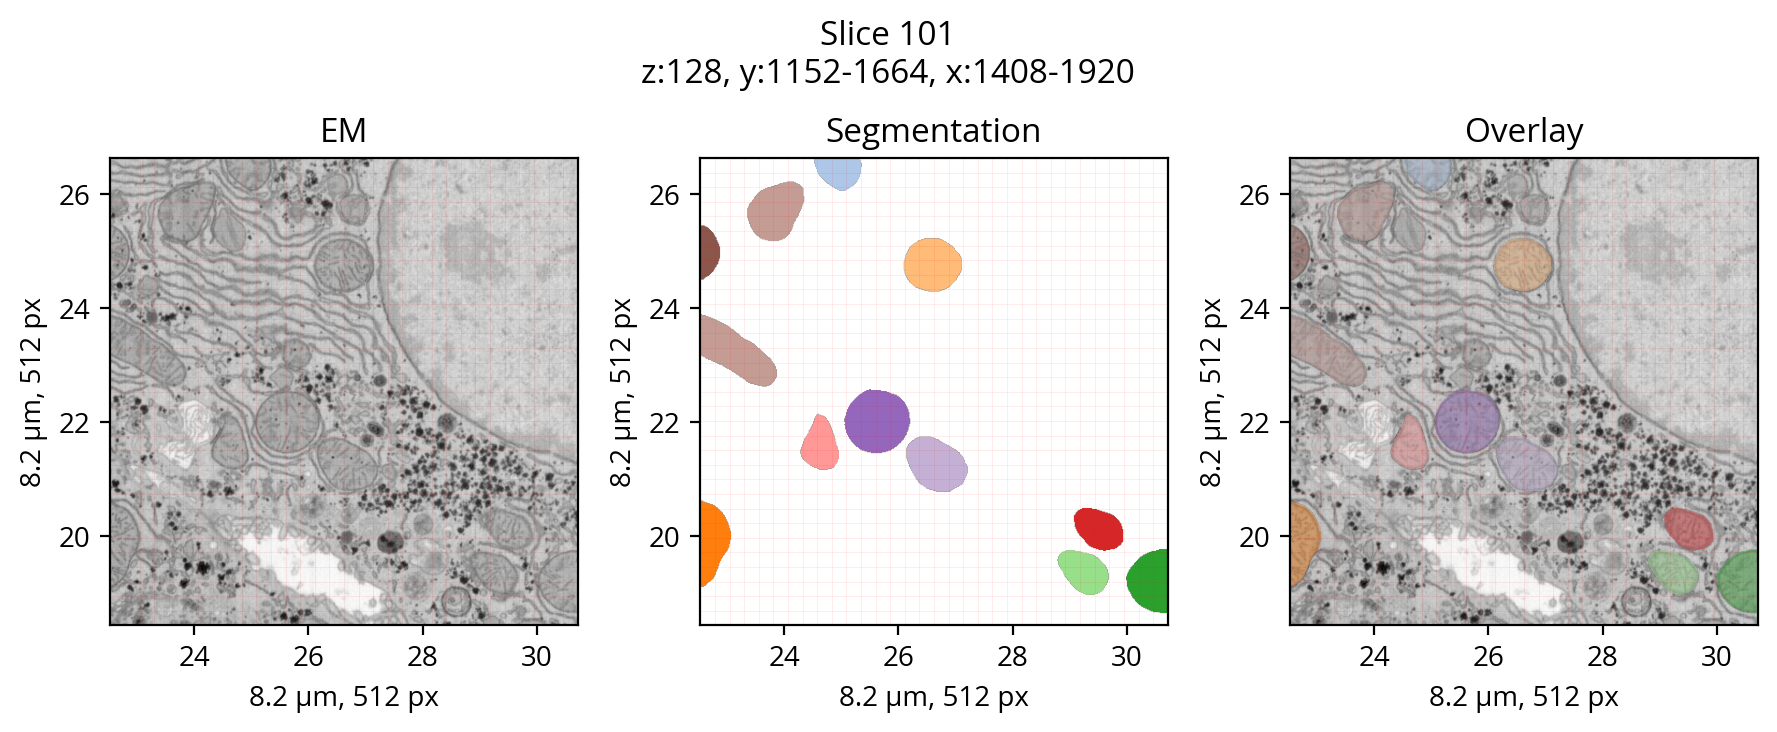

In [6]:
from src.visualizer import Visualizer
vis = Visualizer(data_manager)

slice_index = 101
slc = slices[slice_index]

z_index_to_plot = slc.z.start

# 2D plot — pick any z index within the slice bounds                                                                                    
vis.plot_segmentation_example(slc, z_index=z_index_to_plot, title=f"Slice {slice_index}\n"
    f"z:{slc.z.start}, y:{slc.y.start}-{slc.y.stop}, x:{slc.x.start}-{slc.x.stop}")


In [7]:
from src.model import load_vitb16_model, load_vits16_model, load_vith16plus_model

vits_model = load_vits16_model() # smallest
# vitb_model = load_vitb16_model() # baseline, medium
# vithplus_model = load_vith16plus_model() # largest model

model = vits_model


In [8]:
from src.embeddings import EmbeddingsManager

embeddings_manager = EmbeddingsManager(data_manager, model)

In [9]:
indices = range(0, 2)
slices_subset = [slices[i] for i in indices]

In [10]:
dense_embeddings = embeddings_manager.compute_dense_embeddings(slices_subset)

0/2 - 00:00:01.238


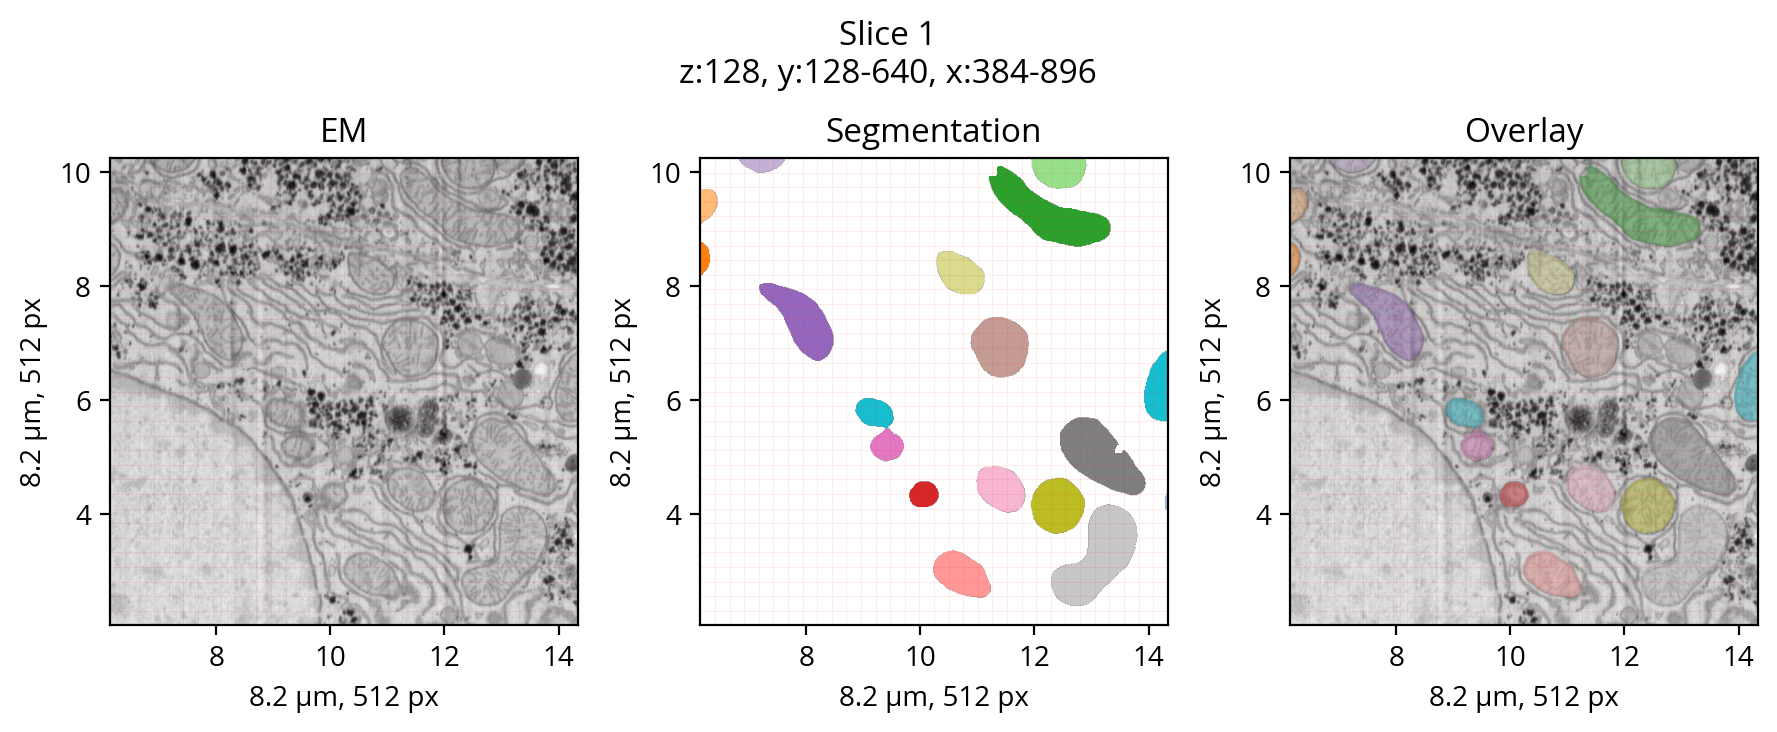

In [11]:
slice_index = 1
slc = slices[slice_index]

z_index_to_plot = slc.z.start
vis.plot_segmentation_example(slc, z_index=z_index_to_plot, title=f"Slice {slice_index}\n"
    f"z:{slc.z.start}, y:{slc.y.start}-{slc.y.stop}, x:{slc.x.start}-{slc.x.stop}")

In [12]:
len(slices)

19008

In [14]:
embeddings_manager.set_slice(slice_index, slc)
mitochondria_ids = embeddings_manager.find_mitochondria_ids()
sample_segment_id = mitochondria_ids[0]

_, reference_vector = embeddings_manager.select_mitochondria_embeddings(sample_segment_id)
distances = embeddings_manager.compute_distances_in_slice_to_reference()

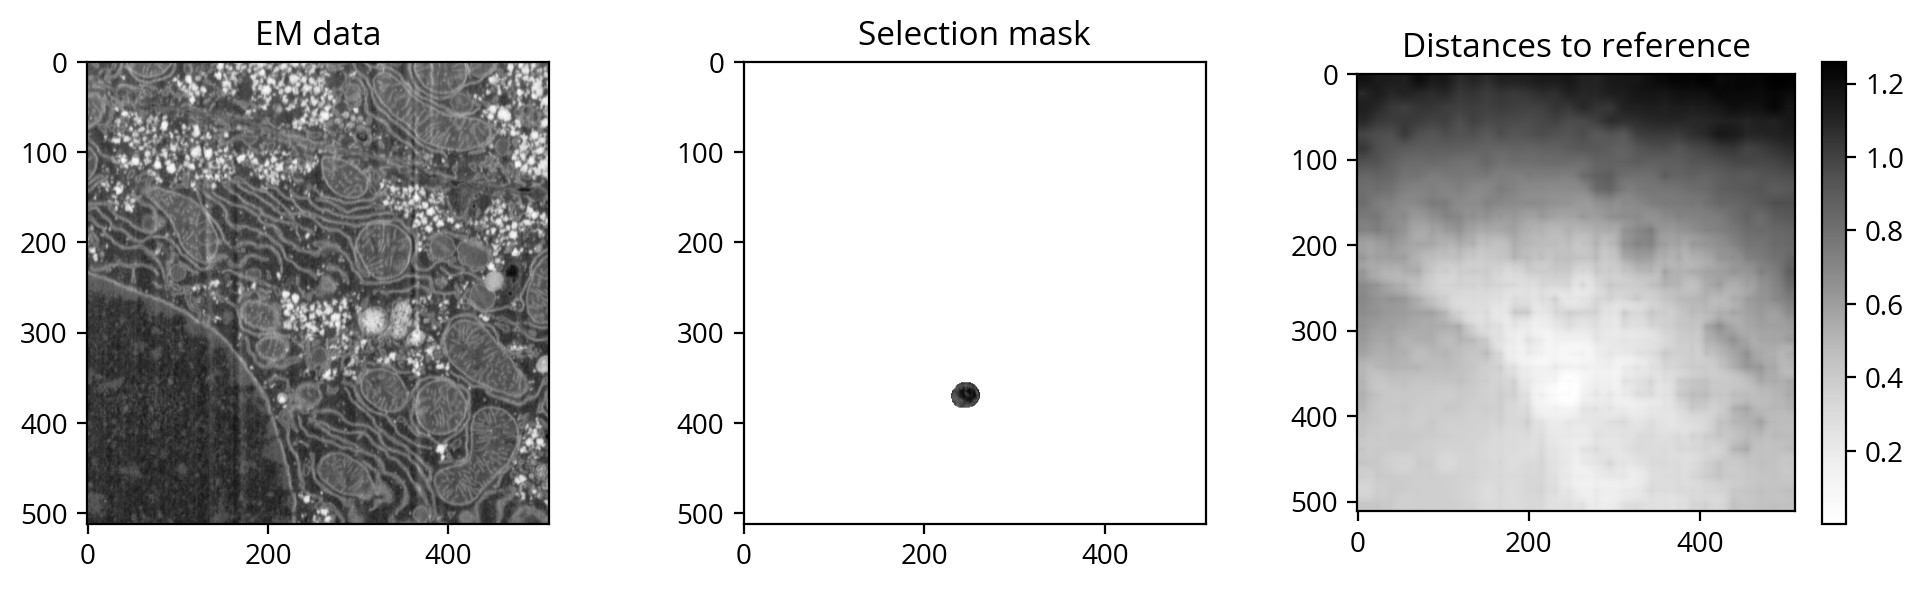

In [15]:
import matplotlib.pyplot as plt

embeddings_manager.plot_distances_to_reference()
plt.colorbar()